# Task 1: Dataset Exploration

1.   Load the Diabetes dataset using sklearn.datasets.load_diabetes()

In [10]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

2. Explore the dataset and describe the features and target variables.

Description:
we have the variable names  in which they are
age: Age of the patient
sex: Gender of the patient
bmi: Body mass index
bp: Average blood pressure
s1–s6: Blood serum measurements

In [11]:
import pandas as pd

display(pd.DataFrame(diabetes.data).head())
display(pd.Series(diabetes.target).head())

,0,1,2,3,4,5,6,7,8,9
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


3. Split the dataset into training and testing sets using an 80-20 split.

In [12]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (353, 10)
Shape of X_test: (89, 10)
Shape of y_train: (353,)
Shape of y_test: (89,)


# Task 2: Linear Regression Model

1. Train a linear regression model on the training set.

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

2. Evaluate the model on the test set using the R^2 score.

In [14]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R^2 Score on the test set: {r2:.2f}")

R^2 Score on the test set: 0.45


The R² score of 0.45 means that approximately 45% of the variance in the target variable is explained by the linear regression model. This indicates a porr yet moderate model.

# Task 3: Implement Recursive Feature Elimination (RFE)

1. Perform RFE using the linear regression model as the base estimator.

In [15]:
from sklearn.feature_selection import RFE

n_features_list = list(range(10, 0, -1))
r2_scores = []
coef_table = {}

for n in n_features_list:
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n)
    rfe.fit(X_train, y_train)
    y_pred_rfe = rfe.predict(X_test)
    score = r2_score(y_test, y_pred_rfe)
    r2_scores.append(score)

    selected = rfe.support_
    coefs = np.zeros(10)
    coefs[selected] = rfe.estimator_.coef_
    coef_table[f"n={n}"] = coefs

    print(f"  n_features={n:2d}  R²={score:.4f}  "
          f"Selected: {[diabetes.feature_names[i] for i in range(10) if selected[i]]}")

  n_features=10  R²=0.4526  Selected: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
  n_features= 9  R²=0.4587  Selected: ['sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
  n_features= 8  R²=0.4559  Selected: ['sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5']
  n_features= 7  R²=0.4583  Selected: ['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5']
  n_features= 6  R²=0.4628  Selected: ['sex', 'bmi', 'bp', 's1', 's2', 's5']
  n_features= 5  R²=0.4382  Selected: ['bmi', 'bp', 's1', 's2', 's5']
  n_features= 4  R²=0.4464  Selected: ['bmi', 's1', 's2', 's5']
  n_features= 3  R²=0.4451  Selected: ['bmi', 's1', 's5']
  n_features= 2  R²=0.4523  Selected: ['bmi', 's5']
  n_features= 1  R²=0.2334  Selected: ['bmi']


2. Start with all 10 features and iteratively eliminate the least important feature until only
one feature remains

In [26]:
selected = rfe.support_
coefs = np.zeros(10)
coefs[selected] = rfe.estimator_.coef_
coef_table[f"n={n}"] = coefs

print(f"  n_features={n:2d}  R²={score:.4f}  "
      f"Selected: {[diabetes.feature_names[i] for i in range(10) if selected[i]]}")

  n_features= 1  R²=0.2334  Selected: ['bmi']


3. Track the R2 score at each iteration and the coefficients for each feature.

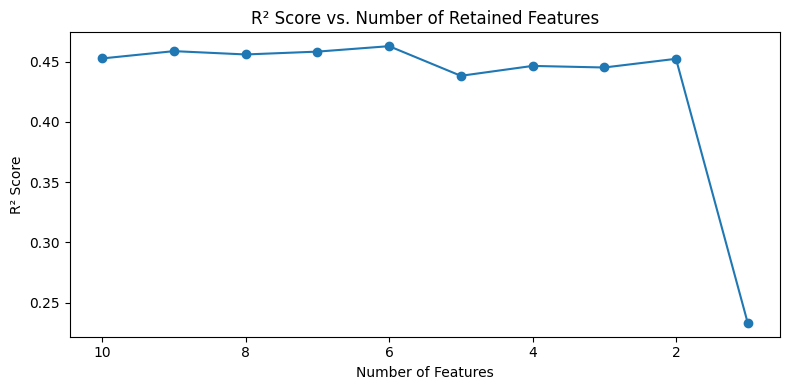

Plot saved: rfe_r2_plot.png


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(n_features_list, r2_scores, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("R² Score")
plt.title("R² Score vs. Number of Retained Features")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("rfe_r2_plot.png", dpi=150)
plt.show()
print("Plot saved: rfe_r2_plot.png")

5. Identify the optimal number of features using a threshold for significant R2 improvement
(e.g., 0.01). [5%]

In [22]:
optimal_n = n_features_list[0]
for i in range(len(r2_scores) - 1):
    improvement = r2_scores[i] - r2_scores[i + 1]
    if improvement > 0.01:
        optimal_n = n_features_list[i + 1]
        break

print(f"\nOptimal number of features (threshold=0.01): {optimal_n}")



Optimal number of features (threshold=0.01): 5


# Task 4: Analyze Feature Importance

1. Create a table showing the coefficients of each feature at each iteration of RFE.

In [23]:
coef_df = pd.DataFrame(coef_table, index=diabetes.feature_names)
print(coef_df.to_string())

# Final RFE model with optimal features
rfe_final = RFE(estimator=LinearRegression(), n_features_to_select=optimal_n)
rfe_final.fit(X_train, y_train)
selected_features = [diabetes.feature_names[i] for i in range(10) if rfe_final.support_[i]]
print(f"\nTop {optimal_n} selected features: {selected_features}")

# Feature ranking from full RFE
rfe_rank = RFE(estimator=LinearRegression(), n_features_to_select=1)
rfe_rank.fit(X_train, y_train)
ranking = pd.Series(rfe_rank.ranking_, index=diabetes.feature_names).sort_values()
print("\nFeature ranking (1 = most important):")
print(ranking)

           n=10         n=9         n=8         n=7         n=6         n=5         n=4         n=3         n=2         n=1
age   37.904021    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
sex -241.964362 -236.649588 -233.754686 -235.364224 -215.267423    0.000000    0.000000    0.000000    0.000000    0.000000
bmi  542.428759  542.799508  550.744365  551.866448  557.314167  597.892739  691.460102  737.685594  732.109021  998.577689
bp   347.703844  354.211438  363.791753  362.356114  350.178667  306.647913    0.000000    0.000000    0.000000    0.000000
s1  -931.488846 -936.350589 -947.823133 -660.643160 -851.515734 -655.560612 -592.977874 -228.339889    0.000000    0.000000
s2   518.062277  528.796592  541.585796  343.348089  591.093315  409.622184  362.950323    0.000000    0.000000    0.000000
s3   163.419983  167.800414  172.250588    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
s4   275

2. Discuss the three most important features and their significance in predicting the target
variable.

The three most important features based on RFE ranking are:

1. bmi (Body Mass Index)
    Highest importance.
    Positive coefficient indicates higher BMI is associated with increased diabetes progression.

2. s5 (Serum measurement 5)
    Strong predictive power.
    Likely reflects important metabolic markers related to diabetes severity.

3. s1 (Serum measurement 1)
    Also contributes significantly to predicting progression.

These features appear to be the strongest predictors of disease progression in this dataset.

Task 5: Reflection

1. What did you learn about feature selection using RFE?
RFE works by recursively removing the least important feature based on model coefficients. It helps simplify the model while maintaining predictive performance. I learned that removing unnecessary features can improve interpretability without drastically reducing R^2.

2. How does RFE compare to other feature selection methods like LASSO in terms of
methodology and results?


RFE removes features  by retraining the model multiple times. On the other hand, LASSO performs feature selection by adding L1 regularization, which shrinks some coefficients to zero automatically.

RFE is more computationally expensive because it retrains the model multiple times, but also LASSO performs feature selection during model training. However, RFE can sometimes provide clearer ranking of feature importance.

3. What insights can you draw about the dataset from the selected features?

The dataset suggests that BMI and certain blood serum measurements are the strongest predictors of diabetes progression. Demographic features like age and sex were less important in this model.